# 2000-2023 initial data analysis on team winning percentage

In [85]:
import pandas as pd
import matplotlib.pyplot as plt

## Read csv and Display Format

In [86]:
df = pd.read_csv("../Data/afl_stats.csv")
df.head()

,Game,Season,Date,Round,Home_Team,Home_Points,Away_Team,Away_Points,Winner,Home_Points_By,...,Home_Points_For_4,Away_Points_For_4,Home_Points_Against_4,Away_Points_Against_4,Home_Points_For_5,Away_Points_For_5,Home_Points_Against_5,Away_Points_Against_5,Home_Rank,Away_Rank
0,11728,2000,2000-03-08,R1,Richmond,94,Melbourne,92,Home,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
1,11729,2000,2000-03-09,R1,Essendon,156,Port Adelaide,62,Home,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
2,11730,2000,2000-03-10,R1,North Melbourne,111,West Coast,154,Away,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
3,11731,2000,2000-03-11,R1,Adelaide,108,Footscray,131,Away,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0
4,11732,2000,2000-03-11,R1,Fremantle,107,Geelong,129,Away,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0


## Declare Helper Functions

In [87]:
# Function to calculate games each team has played
def calculate_team_games(df):
    team_games = {}

    for team in df.Home_Team.unique():
        home_games = df.Home_Team.value_counts()[team]
        away_games = df.Away_Team.value_counts()[team]
    
        team_games[team] = int(home_games + away_games)

    return team_games

# Function to calculate wins for each team
def calculate_team_wins(df):
    team_wins = {}

    for team in df.Home_Team.unique():
        home_wins = ((df['Home_Team'] == team) &
                 (df['Winner'] == 'Home')).sum()
        away_wins = ((df['Away_Team'] == team) &
                 (df['Winner'] == 'Away')).sum()

        team_wins[team] = int(home_wins + away_wins)
        
    return team_wins

# Function to calculate teams home win percentage
def calculate_home_win_percentage(df):
    team_home_win_percentage = {}

    for team in df.Home_Team.unique():
        home_wins = ((df['Home_Team'] == team) &
                     (df['Winner'] == 'Home')).sum()
        home_games = df.Home_Team.value_counts()[team]
    
        team_home_win_percentage[team] = round(home_wins / home_games * 100, 2)
        
    return team_home_win_percentage

# Function to calculate teams away win percentage
def calculate_away_win_percentage(df):
    team_away_win_percentage = {}

    for team in df.Home_Team.unique():
        away_wins = ((df['Away_Team'] == team) &
                 (df['Winner'] == 'Away')).sum()
        away_games = df.Away_Team.value_counts()[team]
    
        team_away_win_percentage[team] = round(away_wins / away_games * 100, 2)

    return team_away_win_percentage

# Function to calculate teams overall win percentage
def calculate_team_win_percentage(team_wins, team_games):
    team_win_percentage = {}

    for team in team_games:
        win_percentage = team_wins[team]/team_games[team] * 100
        win_percentage = float(round(win_percentage, 1))
        team_win_percentage[team] = win_percentage

    return team_win_percentage

# Function to calculate home advantage for all teams
def calculate_home_advantage(df):
    home_advantage = df['Winner'].value_counts(normalize=True) * 100
    home_advantage = round(home_advantage, 2)

    return home_advantage

# Function to calculate average points scored by each team
def calculate_team_avg_points(df, team_games):
    team_points = {}

    for team in df.Home_Team.unique():
        home_df = df[df['Home_Team'] == team]
        home_points = home_df.Home_Points.sum()
    
        away_df = df[df['Away_Team'] == team]
        away_points = away_df.Away_Points.sum()

        points = int(home_points + away_points)
        avg_points = points / team_games[team]
        team_points[team] = round(avg_points, 2)

    return team_points

# Function to calculate teams average winning margin
def calculate_team_avg_winning_margin(df):
    team_avg_winning_margin = {}

    for team in df.Home_Team.unique():
        home_win_filter = ((df['Home_Team'] == team) &
                           (df['Winner'] == 'Home'))
        home_win_df = df[home_win_filter]
        home_margins = (home_win_df['Home_Points'] - home_win_df['Away_Points'])

        away_win_filter = ((df['Away_Team'] == team) &
                           (df['Winner'] == 'Away'))
        away_win_df = df[away_win_filter]
        away_margins = (away_win_df['Away_Points'] - away_win_df['Home_Points'])

        team_avg_winning_margin[team] = round(pd.concat([home_margins, away_margins]).mean(), 2)

    return team_avg_winning_margin

# Function to calculate teams average points conceded
def calculate_team_avg_points_conceded(df, team_games):
    team_points_conceded = {}

    for team in df.Home_Team.unique():
        home_df = df[df['Home_Team'] == team]
        home_points_conceded = home_df.Away_Points.sum()
    
        away_df = df[df['Away_Team'] == team]
        away_points_conceded = away_df.Home_Points.sum()

        points_conceded = int(home_points_conceded + away_points_conceded)
        avg_points_conceded = points_conceded / team_games[team]
        team_points_conceded[team] = round(avg_points_conceded, 2)

    return team_points_conceded


## Run Analysis Functions

In [88]:
team_games = calculate_team_games(df)

team_wins = calculate_team_wins(df)

team_home_win_percentage = calculate_home_win_percentage(df)

team_away_win_percentage = calculate_away_win_percentage(df)

team_win_percentage = calculate_team_win_percentage(team_games, team_wins)

home_advantage = calculate_home_advantage(df)

team_points = calculate_team_avg_points(df, team_games)

team_avg_winning_margin = calculate_team_avg_winning_margin(df)

team_points_conceded = calculate_team_avg_points_conceded(df, team_games)

## Plot home win percentage

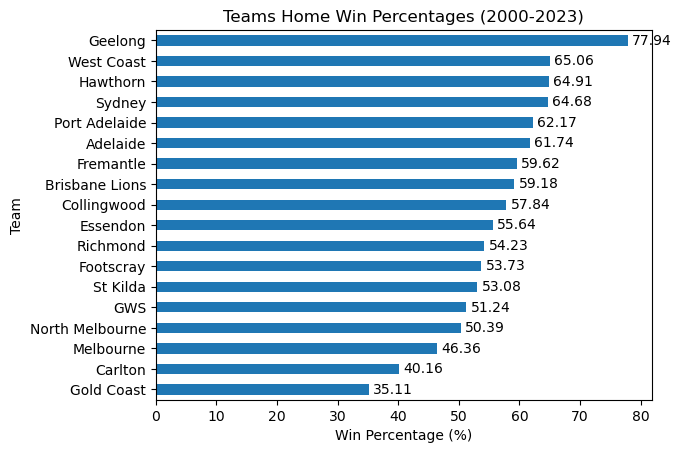

In [89]:
sorted_home_percentage = dict(sorted(team_home_win_percentage.items(), key=lambda item: item[1]))

home_percentage_df = pd.Series(sorted_home_percentage)

ax = home_percentage_df.plot(kind='barh')

for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=3)

plt.title('Teams Home Win Percentages (2000-2023)')
plt.xlabel('Win Percentage (%)')
plt.ylabel('Team')

plt.show()

## Plot away win percentage

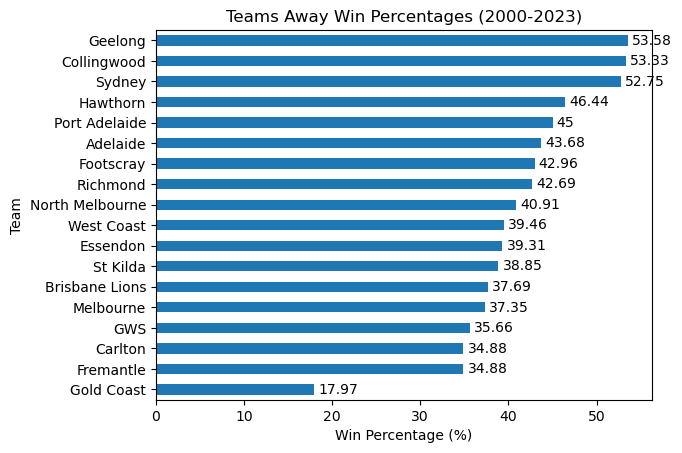

In [90]:
sorted_away_percentage = dict(sorted(team_away_win_percentage.items(), key=lambda item: item[1]))

away_percentage_df = pd.Series(sorted_away_percentage)

ax = away_percentage_df.plot(kind='barh')

for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=3)

plt.title('Teams Away Win Percentages (2000-2023)')
plt.xlabel('Win Percentage (%)')
plt.ylabel('Team')

plt.show()

## Sort win percentage dictionary

In [91]:
sorted_percentage = dict(sorted(team_win_percentage.items(), key=lambda item: item[1]))
print(sorted_percentage)

{'Geelong': 151.2, 'Sydney': 170.4, 'Hawthorn': 179.7, 'Collingwood': 179.9, 'Port Adelaide': 186.2, 'Adelaide': 189.5, 'West Coast': 190.6, 'Brisbane Lions': 205.9, 'Richmond': 206.3, 'Footscray': 207.5, 'Essendon': 211.0, 'Fremantle': 211.4, 'St Kilda': 217.6, 'North Melbourne': 219.5, 'GWS': 231.5, 'Melbourne': 238.7, 'Carlton': 266.7, 'Gold Coast': 375.4}


## Display win percentage graph

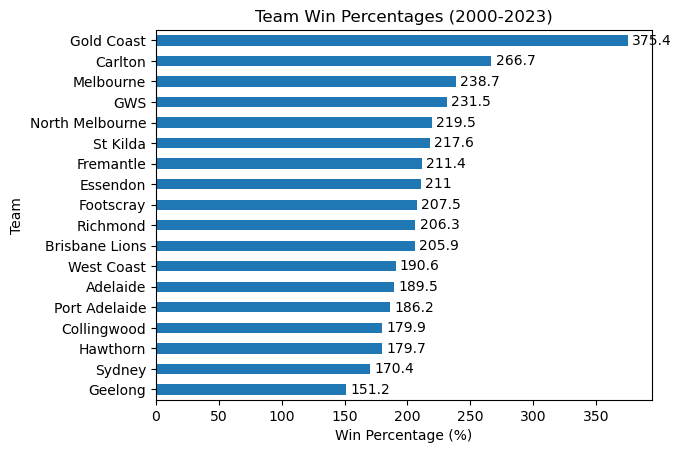

In [92]:
percentage_df = pd.Series(sorted_percentage)

ax = percentage_df.plot(kind='barh')

for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=3)

plt.title('Team Win Percentages (2000-2023)')
plt.xlabel('Win Percentage (%)')
plt.ylabel('Team')

plt.show()

## Plot home advantage

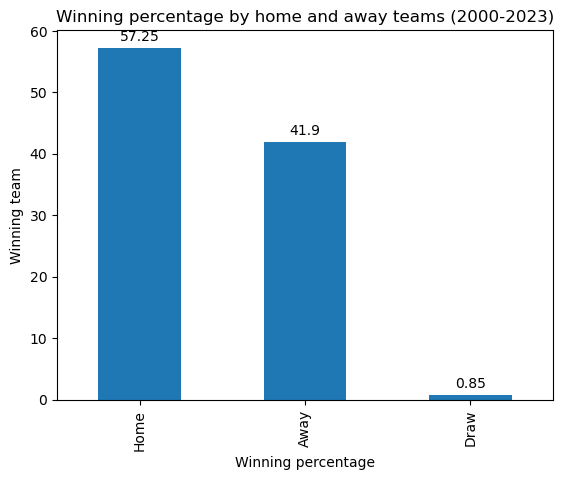

In [93]:
ax = home_advantage.plot(kind='bar')

for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=3)

plt.title("Winning percentage by home and away teams (2000-2023)")
plt.xlabel("Winning percentage")
plt.ylabel("Winning team")

plt.show()

## Plot average points per game per team

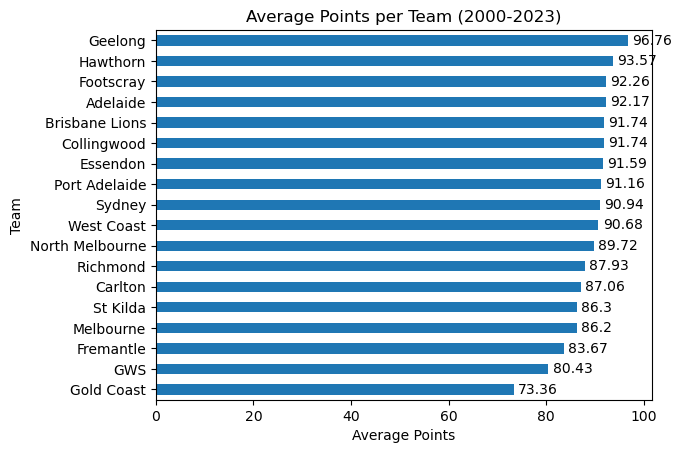

In [94]:
sorted_avg_points = dict(sorted(team_points.items(), key=lambda item: item[1]))

points_avg_df = pd.Series(sorted_avg_points)

ax = points_avg_df.plot(kind='barh')

for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=3)

plt.title('Average Points per Team (2000-2023)')
plt.xlabel('Average Points')
plt.ylabel('Team')

plt.show()

## Plot teams average winning margin

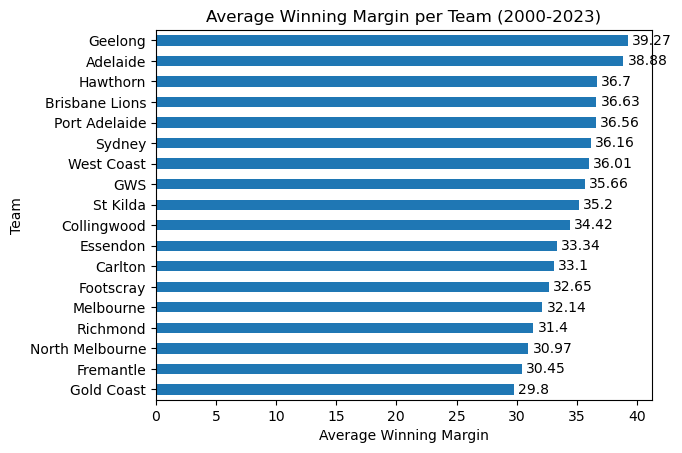

In [95]:
sorted_avg_winning_margin = dict(sorted(team_avg_winning_margin.items(), key=lambda item: item[1]))

avg_winning_margin_df = pd.Series(sorted_avg_winning_margin)

ax = avg_winning_margin_df.plot(kind='barh')

for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=3)

plt.title('Average Winning Margin per Team (2000-2023)')
plt.xlabel('Average Winning Margin')
plt.ylabel('Team')

plt.show()

## Plot average points conceded

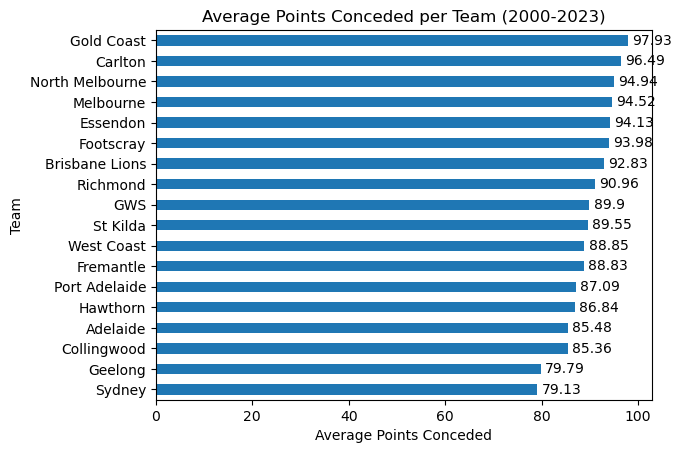

In [96]:
sorted_avg_points_conceded = dict(sorted(team_points_conceded.items(), key=lambda item: item[1]))

points_avg_conceded_df = pd.Series(sorted_avg_points_conceded)

ax = points_avg_conceded_df.plot(kind='barh')

for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=3)

plt.title('Average Points Conceded per Team (2000-2023)')
plt.xlabel('Average Points Conceded')
plt.ylabel('Team')

plt.show()